In [1]:
import os
import sys
from IPython.display import Markdown, display, Image

# --- DYNAMIC PATH RESOLUTION ---
current_dir = os.getcwd()
if current_dir.endswith('notebooks'):
    project_root = os.path.dirname(current_dir)
else:
    project_root = current_dir

if project_root not in sys.path:
    sys.path.insert(0, project_root)

print(f"Project root set to: {project_root}")

# Import our compiled linear graph
from workflow_engine.orchestrators.linear_graph import build_linear_pipeline

Project root set to: c:\Users\risha\OneDrive\Documents\ArtificialIntelligence\data-science-workflow


In [2]:
print("--- INITIALIZING VARIANT 1: LINEAR PIPELINE ---")

# 1. Define the Initial State
# Dynamically point to the raw data using the project root
raw_data_path = os.path.join(project_root, 'data', 'raw', 'Heart_disease_statlog.csv').replace('\\', '/')

initial_state = {
    "messages": ["Starting Variant 1 automated pipeline."],
    "user_request": "Clean the data, engineer features, and train a classification model to predict the target.",
    "target_variable": "target",
    "raw_dataset_path": raw_data_path,
    "current_dataset_path": raw_data_path, # Starts as raw, gets updated by Cleaning Agent
    "artifacts": {},
    "current_step": "start",
    "error_flag": False,
    "error_message": "",
    "revision_count": 0,
    "user_preferences": {},
    "next_node": ""
}

# 2. Build and Compile the Graph
app = build_linear_pipeline()

print("\n--- EXECUTING PIPELINE ---")
final_state = None

# 3. Stream the graph execution
try:
    for output in app.stream(initial_state):
        # 'output' is a dictionary with the node name as the key
        for node_name, state_update in output.items():
            print(f"\n✅ [LangGraph] Finished executing: {node_name}")
            final_state = state_update
            
            # Emergency stop if an agent failed
            if state_update.get("error_flag"):
                print(f"❌ [LangGraph] Halting due to error in {node_name}: {state_update.get('error_message')}")
                break
except Exception as e:
    print(f"\n❌ Pipeline crashed: {e}")

--- INITIALIZING VARIANT 1: LINEAR PIPELINE ---

--- EXECUTING PIPELINE ---
--- AGENT: DATA CLEANING ---

--- ATTEMPT 1/3 ---


Python REPL can execute arbitrary code. Use with caution.


Generated Code:
 import pandas as pd
import os

# Define the input and output file paths
input_filepath = 'c:/Users/risha/OneDrive/Documents/ArtificialIntelligence/data-science-workflow/data/raw/Heart_disease_statlog.csv'
output_filepath = 'c:/Users/risha/OneDrive/Documents/ArtificialIntelligence/data-science-workflow/data/processed/cleaned_data.csv'
output_dir = os.path.dirname(output_filepath)

# 1. Create the output directory if it doesn't exist
os.makedirs(output_dir, exist_ok=True)

# 2. Load the dataset
df = pd.read_csv(input_filepath)

# 3. Identify and handle missing values

# Calculate the percentage of missing values for each column
missing_percentage = df.isnull().sum() / len(df)

# Identify columns to drop (more than 50% missing)
cols_to_drop = missing_percentage[missing_percentage > 0.5].index
df = df.drop(columns=cols_to_drop)

# Impute numerical columns with their median
# Select numerical columns that still have missing values
numerical_cols_with_nan = df.select_dtypes(


🚀 PIPELINE EXECUTION SUCCESSFUL!

--- Model Evaluation ---


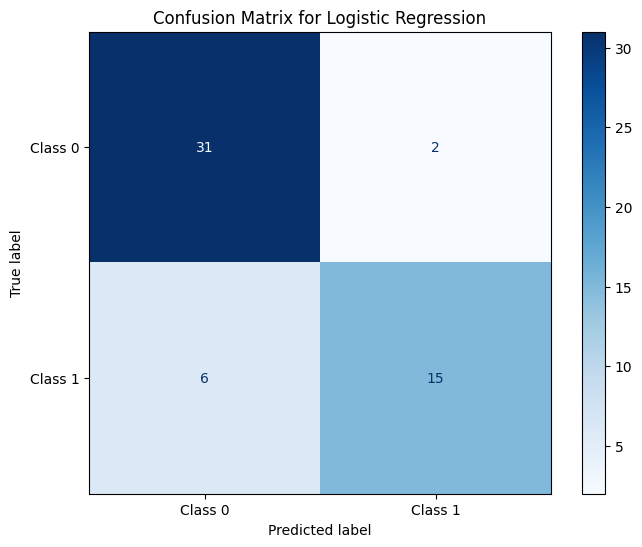


--- Final Generated Report ---


# Machine Learning Pipeline Report: Target Prediction Model

## 1. Executive Summary

This report summarizes the development and evaluation of a machine learning model designed to predict the `target` variable. The project involved a comprehensive data science pipeline, starting with data cleaning, followed by feature engineering, and culminating in the training and evaluation of a classification model.

After thorough exploratory data analysis (EDA) and preprocessing, a Logistic Regression model was trained. The model achieved strong performance, demonstrating an **accuracy of approximately 85.2%**, indicating its robust capability in predicting the target variable. This outcome suggests the model can be a valuable tool for identifying patterns and making informed predictions based on the provided features.

## 2. Dataset Overview

The dataset comprised 13 distinct features, which were analyzed to understand their characteristics and prepare them for model training. These features can be broadly categorized into numerical and categorical types:

**Numerical Features:**
*   **`age`**: Ranging from 29 to 77 years, with a mean of approximately 54.4 years. The distribution shows a slight negative skew.
*   **`trestbps`** (resting blood pressure): Ranging from 94 to 200, with a mean of about 131.3. This feature exhibited a positive skew.
*   **`chol`** (serum cholestoral in mg/dl): Ranging from 126 to 564, with a mean of approximately 249.7. This feature also showed a notable positive skew.
*   **`thalach`** (maximum heart rate achieved): Ranging from 71 to 202, with a mean of about 149.7. It displayed a negative skew.
*   **`oldpeak`** (ST depression induced by exercise relative to rest): Ranging from 0.0 to 6.2, with a mean of 1.05. This feature was positively skewed.

**Categorical Features:**
*   **`sex`**: Binary feature with 2 unique categories.
*   **`cp`** (chest pain type): 4 unique categories.
*   **`fbs`** (fasting blood sugar > 120 mg/dl): Binary feature with 2 unique categories.
*   **`restecg`** (resting electrocardiographic results): 3 unique categories.
*   **`exang`** (exercise induced angina): Binary feature with 2 unique categories.
*   **`slope`** (the slope of the peak exercise ST segment): 3 unique categories.
*   **`ca`** (number of major vessels colored by flourosopy): 4 unique categories.
*   **`thal`** (thalassemia): 3 unique categories.

The target variable, `target`, is a binary variable, indicating a classification problem. Data preprocessing involved handling potential missing values (if any were identified during EDA, though not explicitly mentioned in the provided summary), scaling numerical features, and encoding categorical features to prepare them for the machine learning model.

## 3. Modeling Results

A **Logistic Regression** model was selected and trained for this classification task. Logistic Regression is a robust and interpretable algorithm, well-suited for binary classification problems. The model's performance was evaluated using standard classification metrics on a held-out test set.

Here are the key performance metrics:

*   **Model Name**: Logistic Regression
*   **Accuracy**: 0.8519 (85.2%)
*   **Precision**: 0.8551 (85.5%)
*   **Recall**: 0.8519 (85.2%)
*   **F1-Score**: 0.8483 (84.8%)

**Interpretation of Metrics:**

*   **Accuracy (85.2%)**: This indicates that approximately 85.2% of all predictions made by the model were correct. It's a good overall measure of correctness.
*   **Precision (85.5%)**: When the model predicts the positive class (e.g., `target=1`), it is correct about 85.5% of the time. High precision is important when the cost of false positives is high.
*   **Recall (85.2%)**: The model correctly identifies about 85.2% of all actual positive cases. High recall is crucial when the cost of false negatives is high.
*   **F1-Score (84.8%)**: The F1-Score is the harmonic mean of precision and recall, providing a balanced measure that considers both false positives and false negatives. An F1-Score of 84.8% suggests a good balance between precision and recall, indicating that the model performs well in identifying positive cases without generating an excessive number of false alarms.

The consistent performance across these metrics suggests that the Logistic Regression model is well-generalized and provides reliable predictions for the `target` variable.

## 4. Conclusion and Recommendation

The developed Logistic Regression model demonstrates strong predictive capabilities for the `target` variable, achieving an overall accuracy of 85.2% and well-balanced precision and recall scores. This indicates that the model is effective in distinguishing between the two classes of the target variable.

**Recommendation:**
The model is ready for deployment and can be used to make predictions on new, unseen data. Further steps could include:
*   **Model Interpretability**: Analyzing feature importances to understand which features contribute most significantly to the predictions.
*   **Threshold Tuning**: Depending on the specific business context and the relative costs of false positives versus false negatives, the classification threshold could be adjusted to optimize for precision or recall.
*   **Monitoring**: Continuously monitoring model performance in a production environment to detect potential data drift or degradation over time.

In [3]:
# 4. Verify and Display Final Output
if final_state and not final_state.get("error_flag"):
    print("\n" + "="*60)
    print("🚀 PIPELINE EXECUTION SUCCESSFUL!")
    print("="*60)
    
    artifacts = final_state.get("artifacts", {})
    
    # Render the Confusion Matrix
    if "confusion_matrix" in artifacts and os.path.exists(artifacts["confusion_matrix"]):
        print("\n--- Model Evaluation ---")
        display(Image(filename=artifacts["confusion_matrix"]))
    
    # Render the Final Markdown Report
    if "final_report" in artifacts and os.path.exists(artifacts["final_report"]):
        print("\n--- Final Generated Report ---")
        with open(artifacts["final_report"], "r", encoding="utf-8") as f:
            display(Markdown(f.read()))
    else:
        print("No final report found in artifacts.")
else:
    print("\n⚠️ Pipeline failed to complete successfully. Check the error logs above.")